# HOMO light-map efficiency analysis
This notebook uses the reusable `analyse_lightmap.py` module. It reports both relative spread definitions—coefficient of variation and `(max-min)/mean`—and writes ten x-y efficiency maps, one for each z slice. For a ROOT-map input it also separates the response into X-, Y-, and Z-directed fibre views, maps the view-to-view RMS, and plots efficiency versus distance to the nearest fibre axis.

In [1]:
from pathlib import Path
from IPython.display import display, Image
from analyse_lightmap import read_efficiencies, read_view_efficiencies, analyse

In [2]:
# Use the merged ROOT map: the efficiency CSV contains only the total.
input_file = Path('lightmaps/homo_response_10bin_5m_0p4mm_100kPhotons.root')
#input_file = Path('lightmaps/homo_response_10bin_5m_0p4mm_fibre-2p0mm_100kPhotons.root')
label = '1 mm fibre diameter, scattering 0.4 mm, absorption 5 m'
output_dir = Path('lightmap_analysis') / input_file.stem
efficiencies = read_efficiencies(input_file)
view_efficiencies = read_view_efficiencies(input_file, efficiencies)
result = analyse(efficiencies, label, output_dir, view_efficiencies)
result

1 mm fibre diameter, scattering 0.4 mm, absorption 5 m: 970 positions
  mean=0.8705199897, std=0.001756032753, CV=0.201722%
  skewness=-0.624364, excess kurtosis=-0.241083
  min=0.86529 at (3.5, 29.5, 907.5) mm
  max=0.87503, relative spread (max-min)/mean=1.118871%
  plots and summary: lightmap_analysis/homo_response_10bin_5m_0p4mm_100kPhotons


{'setting': '1 mm fibre diameter, scattering 0.4 mm, absorption 5 m',
 'positions': 970,
 'mean': 0.8705199896907213,
 'std': 0.0017560327533453234,
 'coefficient_of_variation': 0.002017222779650594,
 'skewness': -0.6243641411021817,
 'excess_kurtosis': -0.24108336131338914,
 'min': 0.865289999999999,
 'max': 0.8750299999999996,
 'relative_spread': 0.011188714923664267,
 'min_x_mm': 3.5,
 'min_y_mm': 29.5,
 'min_z_mm': 907.5}

Warning in <TClass::Init>: no dictionary for class ND::TND280Event is available
Warning in <TClass::Init>: no dictionary for class ND::TDataVector is available
Warning in <TClass::Init>: no dictionary for class ND::TData is available
Warning in <TClass::Init>: no dictionary for class ND::TDatum is available
Warning in <TClass::Init>: no dictionary for class ND::TND280Context is available
Warning in <TClass::Init>: no dictionary for class ND::TSHAHashValue is available
Warning in <TClass::Init>: no dictionary for class ND::TAlignmentId is available
Warning in <TClass::Init>: no dictionary for class ND::TND280Event::Header is available


## Radial efficiency around the fibres
Each source subvoxel is assigned its shortest perpendicular distance to any of the three fibre axes. The points show individual total efficiencies; the connected points and error bars show the mean and population RMS at each discrete distance.

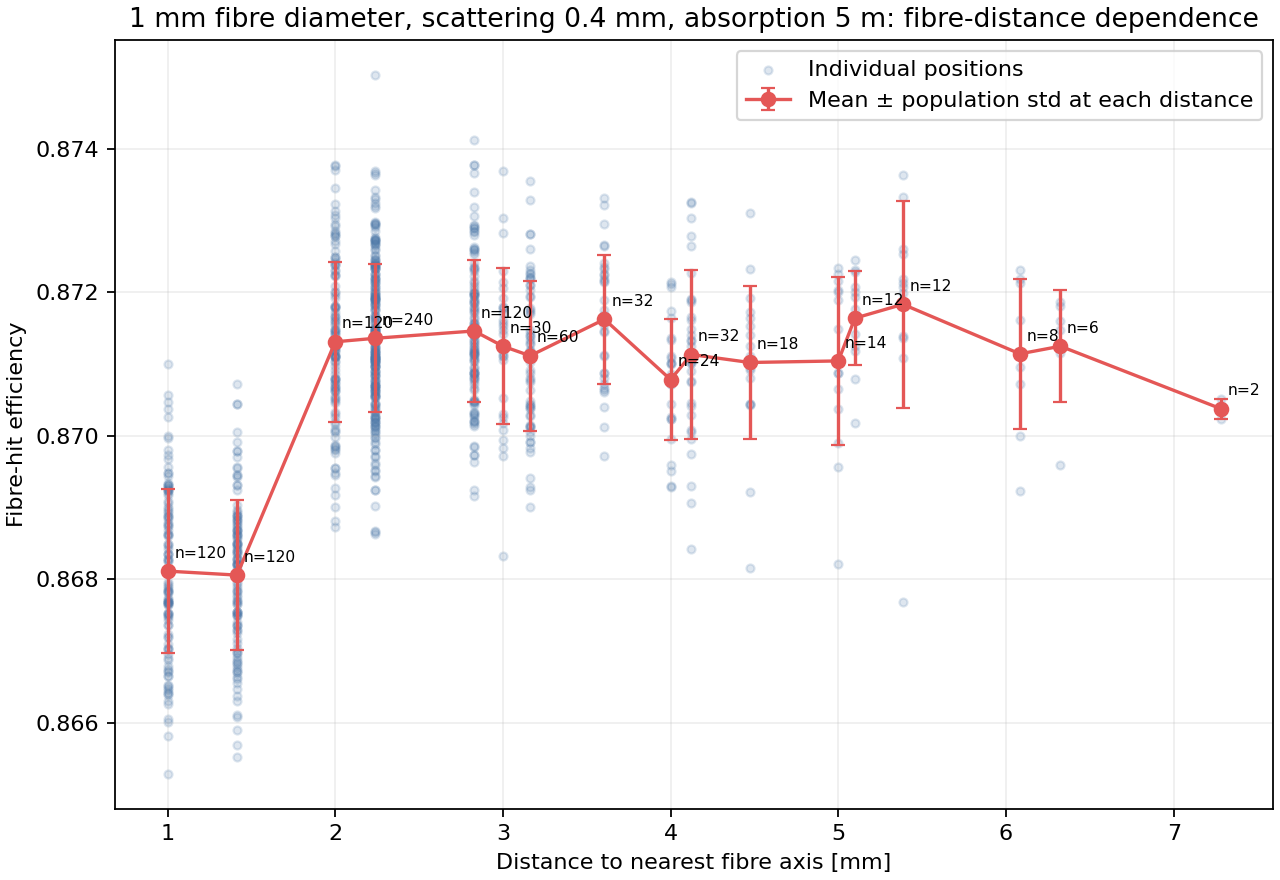

In [3]:
display(Image(filename=str(output_dir / 'efficiency_vs_fibre_distance.png')))

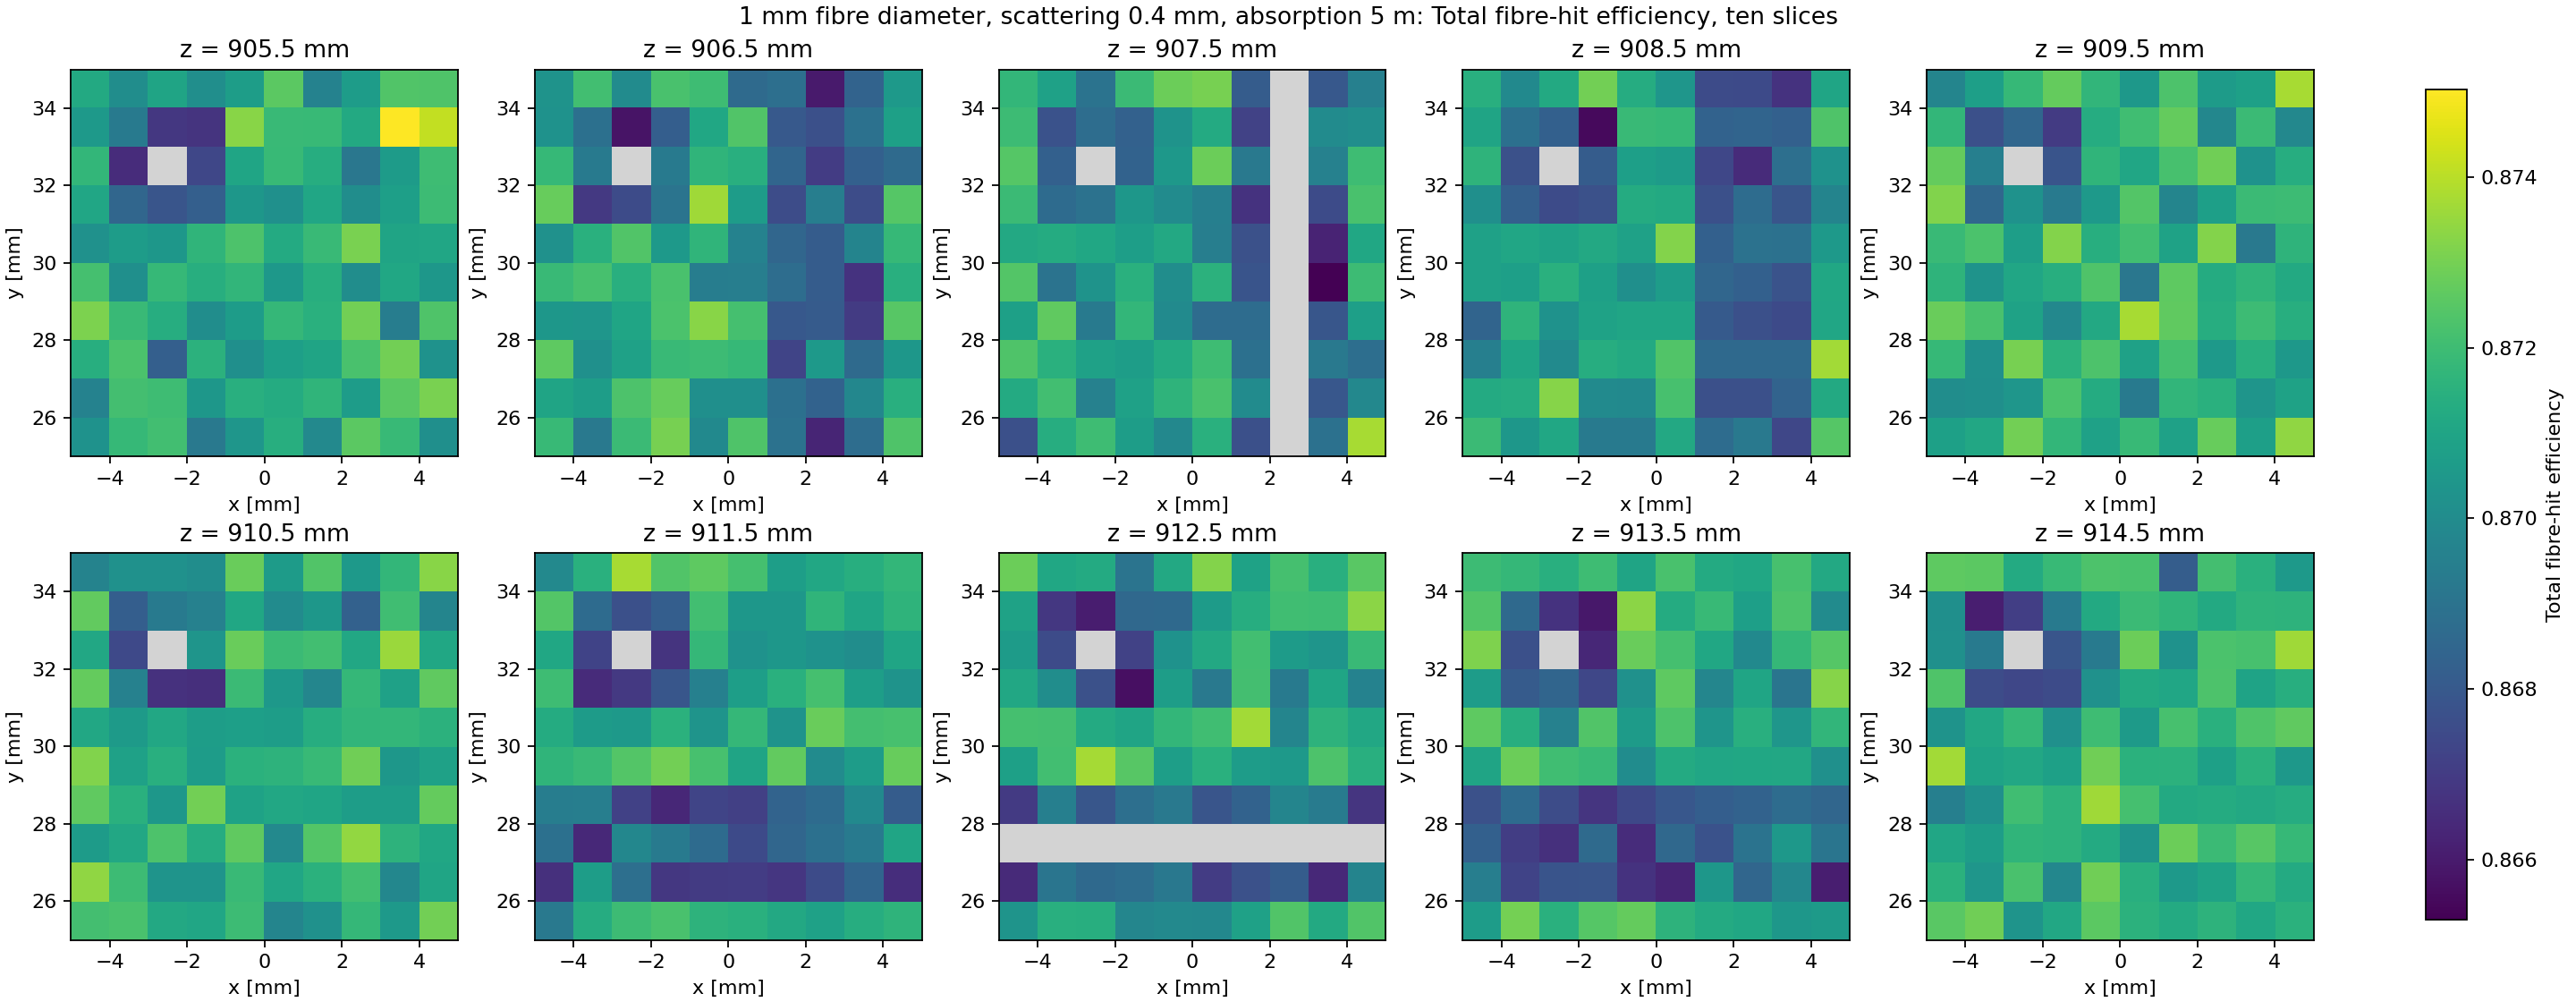

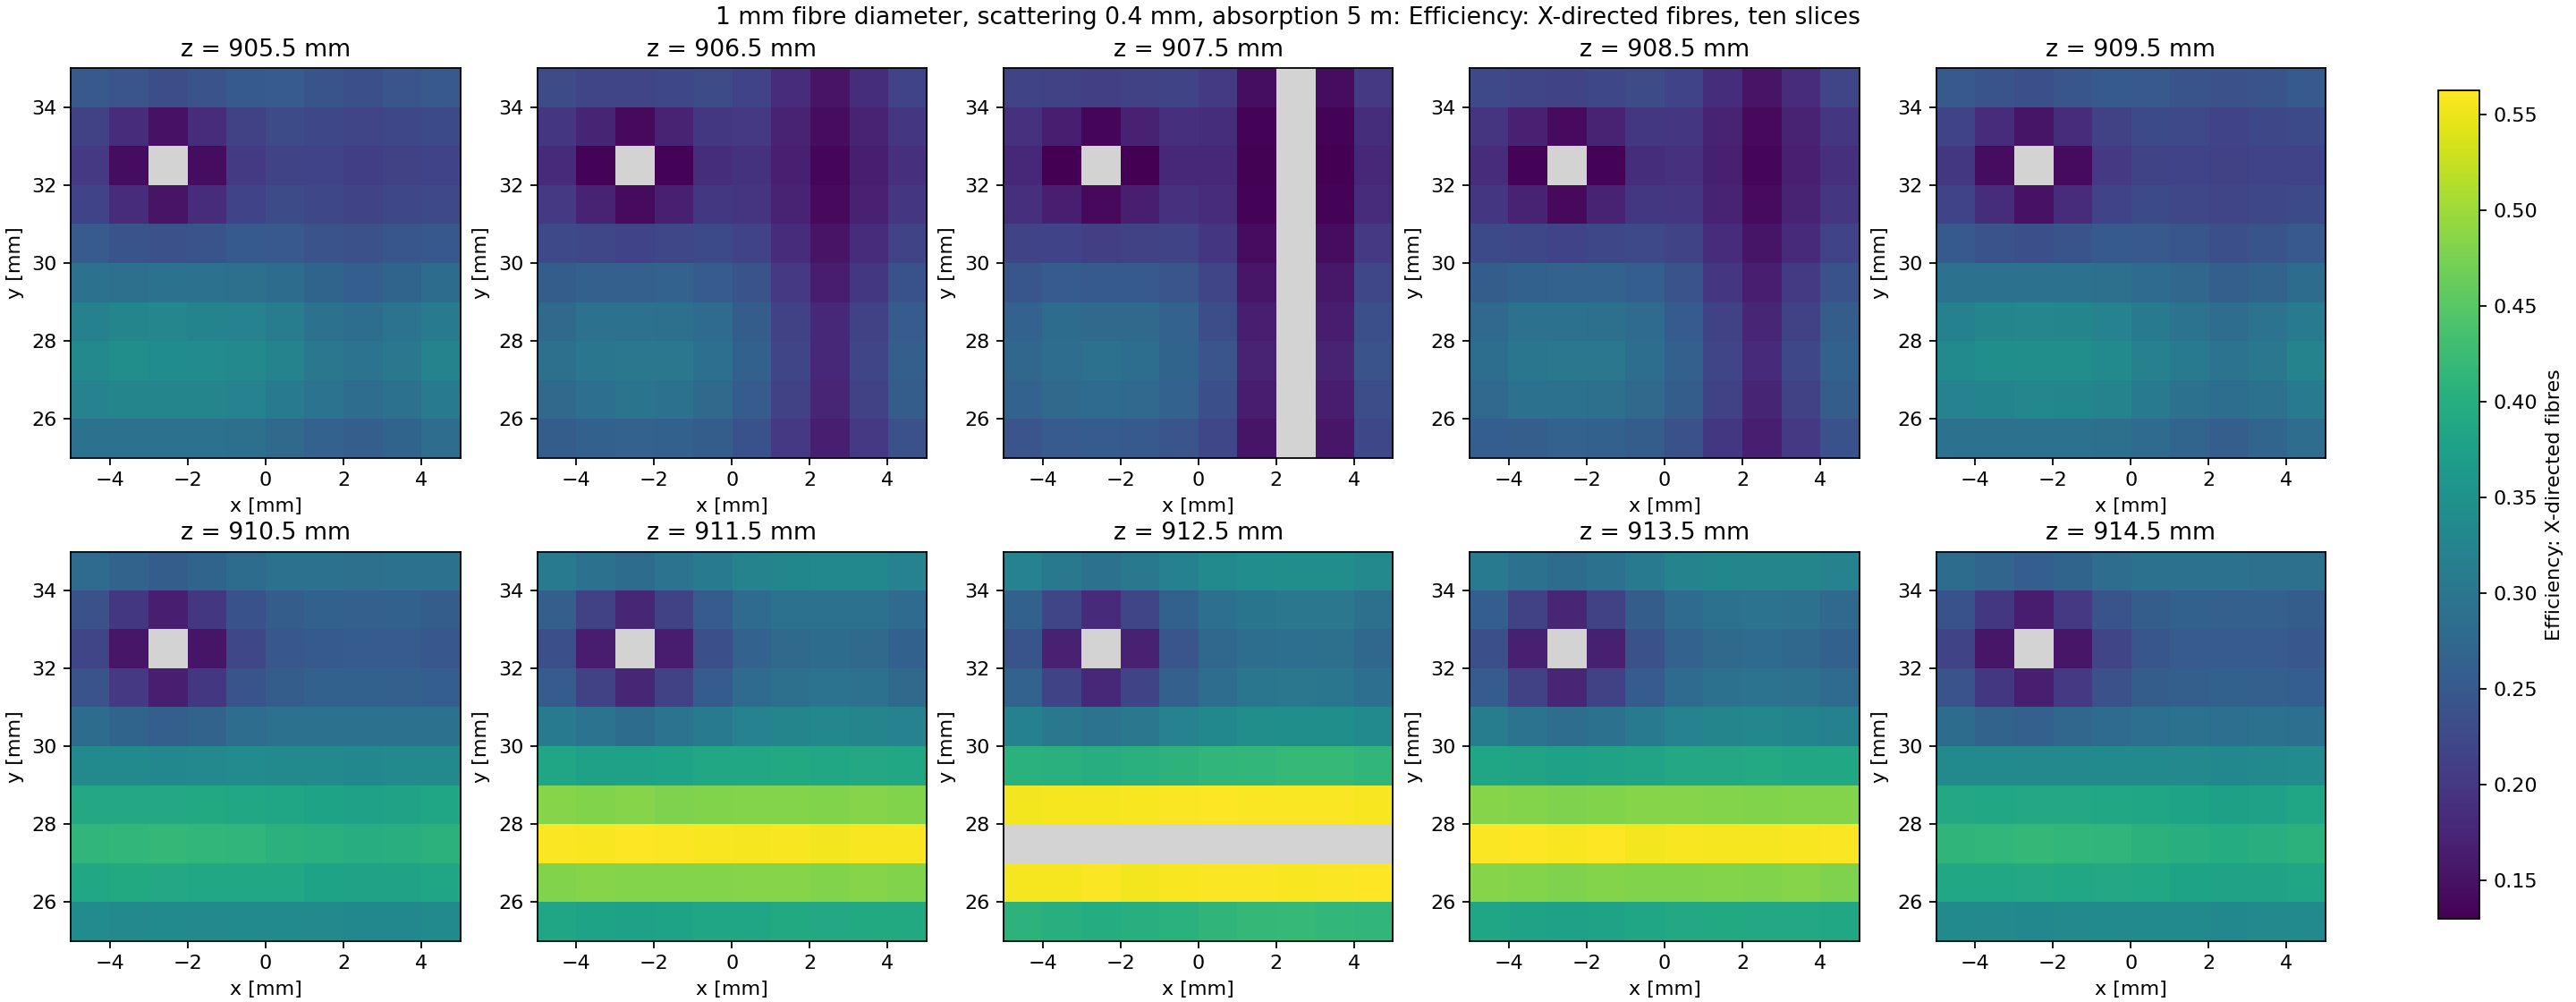

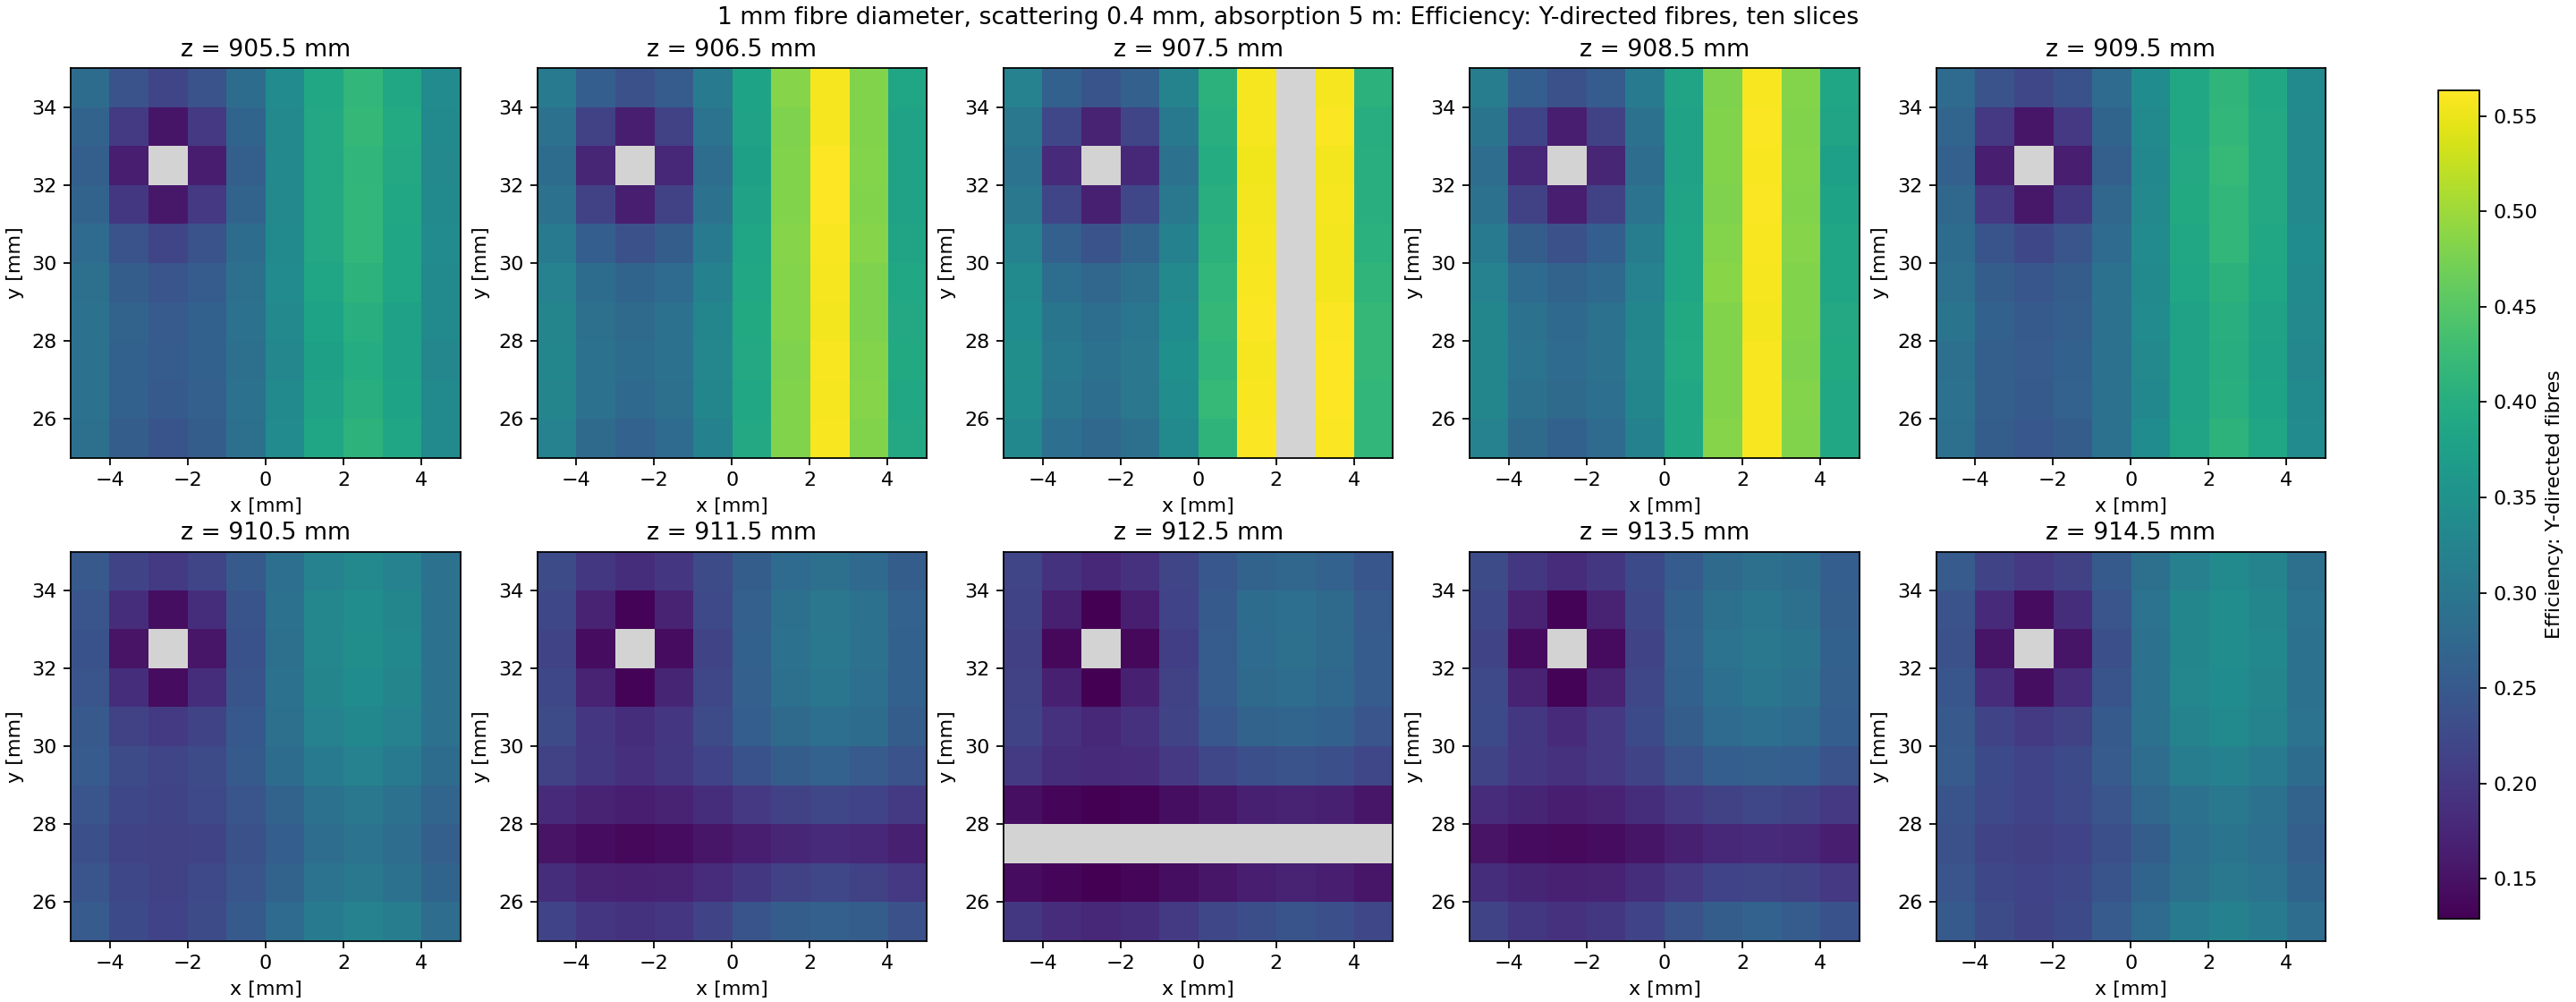

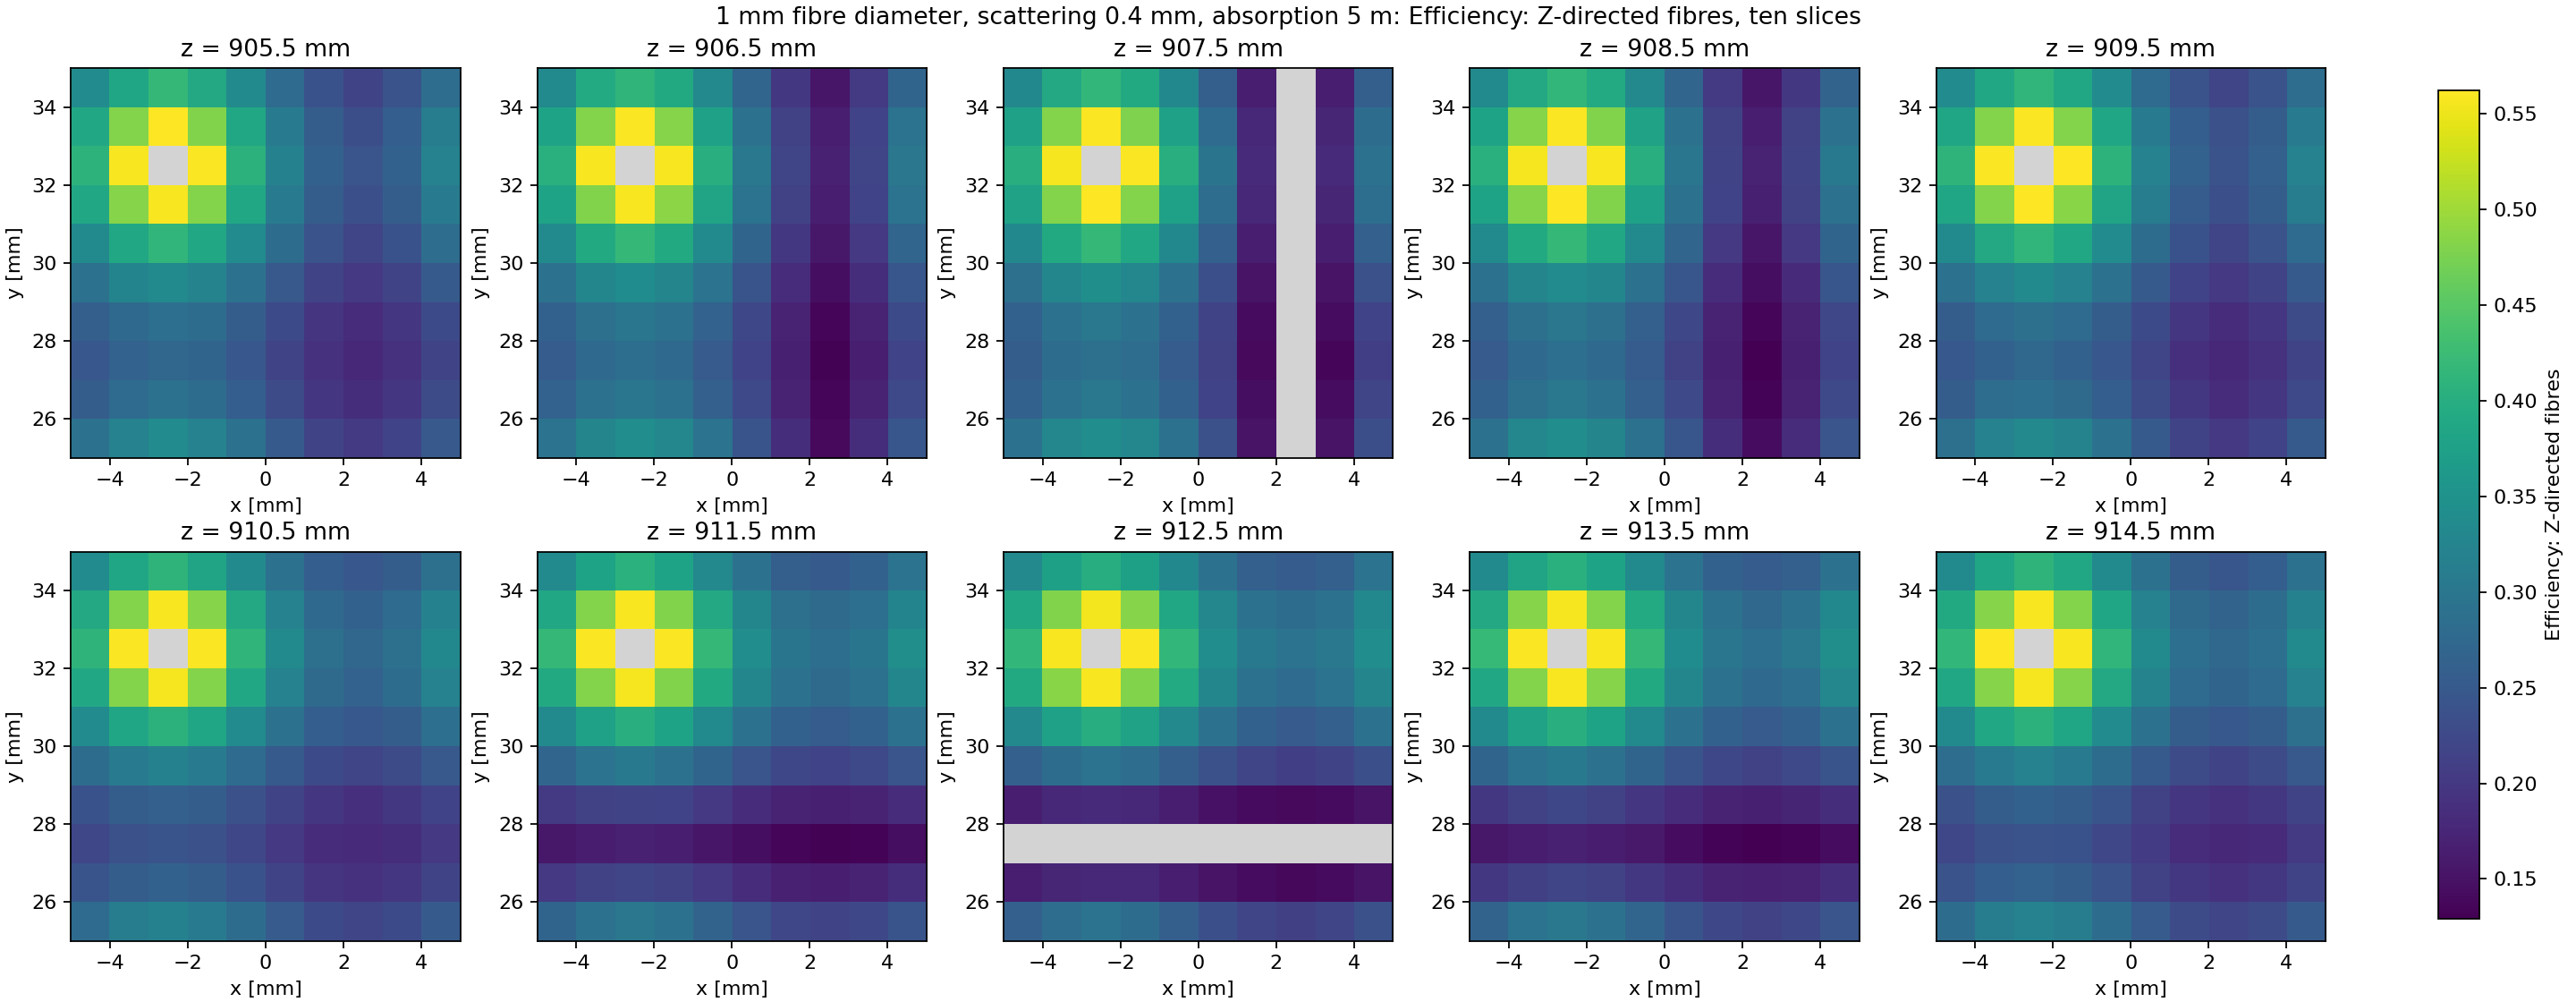

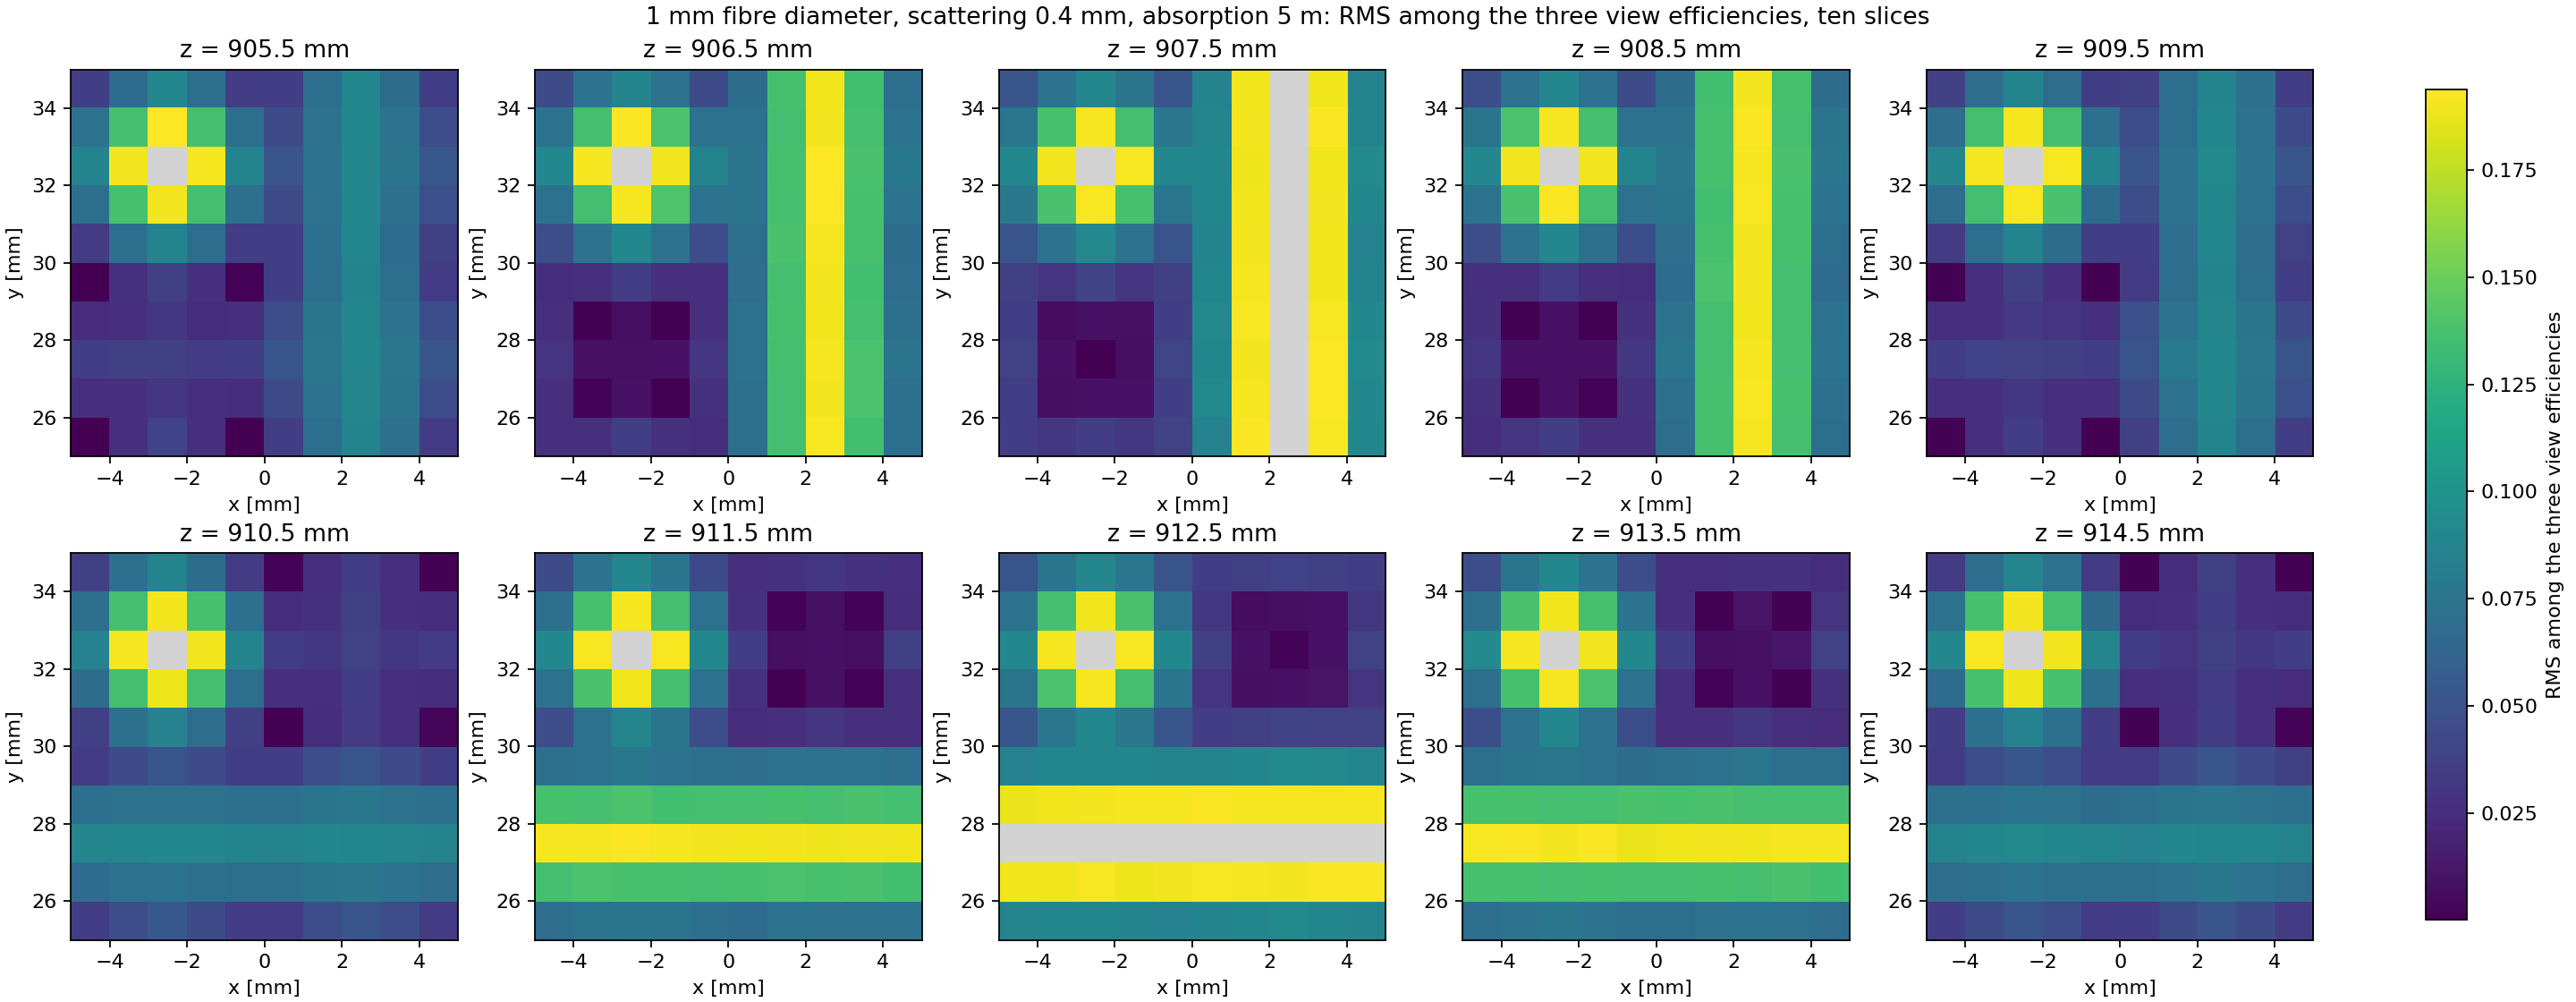

In [4]:
# Display the ten-slice overviews. All panels for a quantity share one scale.
for name in ('total_efficiency', 'x_fibre_efficiency', 'y_fibre_efficiency', 'z_fibre_efficiency', 'view_efficiency_rms'):
    display(Image(filename=str(output_dir / f'{name}_10_slices.png')))

Grey cells in the slice plots are the 30 fibre-source positions excluded by the established geometry mask.